# ML-Enhanced Regime Detection & Signal Scoring

This notebook validates the ML components (regime classifier, signal scorer) against the existing rule-based baseline.

## Objectives
1. Generate regime labels using rule-based RegimeDetector
2. Train ML RegimeClassifier and compare vs rule-based accuracy
3. Generate signal features from historical signals
4. Train SignalScorer on profitable vs unprofitable trades
5. Walk-forward validation with embargo periods
6. Compare ML-enhanced vs rule-based regime detection

## Configuration

In [1]:
import yfinance as yf

CONFIG = {
    "data": {
        "ticker": "SPY",
        "start": "2015-01-01",
        "end": "2024-12-31",
    },
    "regime": {
        "adx_threshold": 25,
        "atr_window": 14,
        "atr_percentile": 80,
    },
    "ml": {
        "regime_model": "random_forest",
        "signal_model": "gradient_boosting",
        "n_estimators": 100,
        "max_depth": 5,
        "random_state": 42,
        "test_size": 0.3,
    },
    "walk_forward": {
        "train_size": 300,
        "step_size": 100,
        "embargo_days": 10,
    },
    "output": {
        "report_path": "../reports/ml_validation/",
    },
}

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 1. Load and Prepare Data

In [3]:
df = yf.download(CONFIG["data"]["ticker"], start=CONFIG["data"]["start"], end=CONFIG["data"]["end"], auto_adjust=True)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.rename(columns={"High": "High", "Low": "Low", "Close": "Close", "Open": "Open", "Volume": "Volume"})
df.index.name = "date"
df = df.sort_index()

print(f"Data loaded: {len(df)} bars, columns: {df.columns.tolist()}")
df.head()

[*********************100%***********************]  1 of 1 completed

Data loaded: 2515 bars, columns: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
date,,,,,
2015-01-02,170.124954,171.325768,169.089778,170.911698,121465900
2015-01-05,167.052612,169.247181,166.746204,169.081555,169632600
2015-01-06,165.479141,167.880745,164.684120,167.359012,209151400
2015-01-07,167.541214,167.880755,166.356978,166.804169,125346700
2015-01-08,170.514206,170.729531,168.932466,168.949020,147217800


## 2. Generate Rule-Based Regime Labels

In [4]:
from src.indicators.regime_detector import RegimeDetector

detector = RegimeDetector()
regime_series = detector.classify(df)
df["regime"] = regime_series

regime_result = detector.get_regime_series(df)
regime_labels = regime_result["regime"].apply(lambda r: r.value)
df["adx"] = regime_result["adx"]
df["atr"] = regime_result["atr"]

print("Regime distribution:")
print(regime_labels.value_counts().sort_index())
print(f"\nRegime classes: {sorted(regime_labels.unique())}")

Regime distribution:
regime
Ranging        938
Transition     100
Trending      1177
Volatile       300
Name: count, dtype: int64

Regime classes: ['Ranging', 'Transition', 'Trending', 'Volatile']


### Regime Time Series Visualization

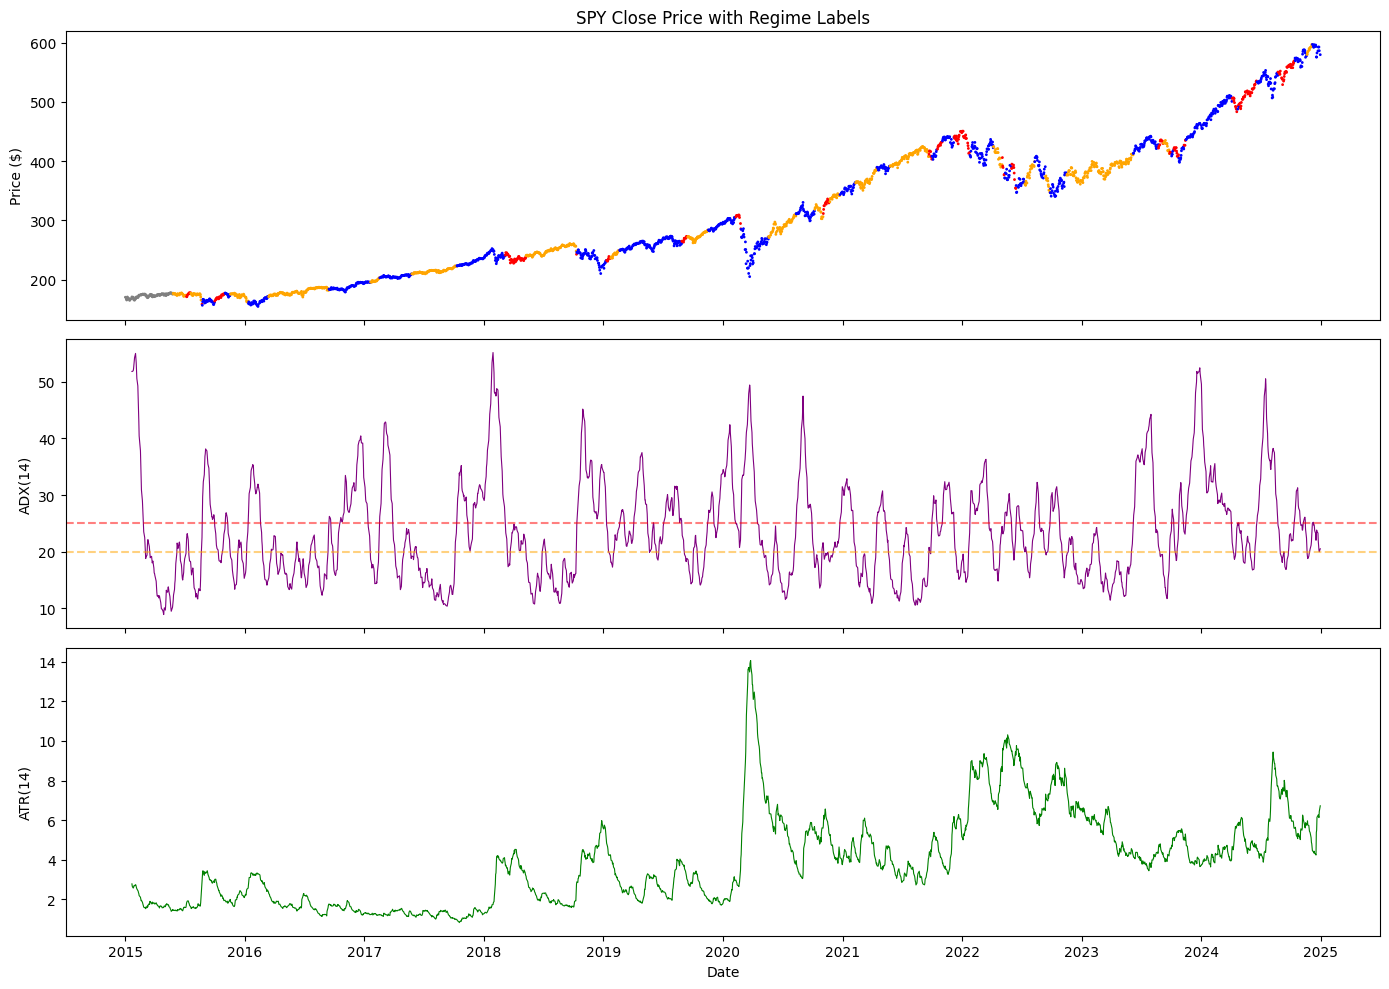

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors = {"Trending": "blue", "Ranging": "orange", "Volatile": "red", "Transition": "gray"}
regime_colors = regime_labels.map(colors)

axes[0].scatter(df.index, df["Close"], c=regime_colors, s=1)
axes[0].set_title("SPY Close Price with Regime Labels")
axes[0].set_ylabel("Price ($)")

axes[1].plot(df.index, df["adx"], color="purple", linewidth=0.8)
axes[1].axhline(y=25, color="red", linestyle="--", alpha=0.5)
axes[1].axhline(y=20, color="orange", linestyle="--", alpha=0.5)
axes[1].set_ylabel("ADX(14)")

axes[2].plot(df.index, df["atr"], color="green", linewidth=0.8)
axes[2].set_ylabel("ATR(14)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 3. Train ML Regime Classifier

In [6]:
from src.ml.regime_model import RegimeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Generate Features for ML

In [7]:
from src.ml.features import FeatureEngineer

engineer = FeatureEngineer()
features_df = engineer.generate_features(df)

numeric_features = features_df.select_dtypes(include=[np.number])
numeric_features = numeric_features.ffill().bfill().dropna()

print(f"Generated {len(numeric_features.columns)} features, {len(numeric_features)} samples")
print(f"Features: {list(numeric_features.columns[:20])}...")

C:\Dev\projects\investment_trying\src\ml\features.py:541: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_5"] = -vol_rank5.rolling(5).corr(high_rank5).rolling(3).max()
C:\Dev\projects\investment_trying\src\ml\features.py:545: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_11"] = (
C:\Dev\projects\investment_trying\src\ml\features.py:552: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

C:\Dev\projects\investment_trying\src\ml\features.py:610: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_57"] = -(close - vwap_approx) / (decay_r.abs() + 1e-10) * 0.01


Generated 125 features, 2515 samples
Features: ['return_5', 'log_return_5', 'return_10', 'log_return_10', 'return_20', 'log_return_20', 'return_50', 'log_return_50', 'price_to_ma_5', 'price_to_ma_10', 'price_to_ma_20', 'price_to_ma_50', 'hl_range', 'oc_range', 'gap', 'dist_to_high_5', 'dist_to_low_5', 'dist_to_high_10', 'dist_to_low_10', 'dist_to_high_20']...


C:\Dev\projects\investment_trying\src\ml\features.py:615: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_65"] = -ts_r * np.sign(close.diff(7))
C:\Dev\projects\investment_trying\src\ml\features.py:619: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_68"] = np.where(high.rolling(9).corr(adv15) < close.diff(3), -1.0, 1.0)
C:\Dev\projects\investment_trying\src\ml\features.py:626: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

In [8]:
y = regime_labels.reindex(numeric_features.index)
y = y.dropna()

X = numeric_features.reindex(y.index)

print(f"Final dataset: X={X.shape}, y={y.shape}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")

Final dataset: X=(2515, 125), y=(2515,)
Target distribution:
regime
Ranging        938
Transition     100
Trending      1177
Volatile       300
Name: count, dtype: int64


### Train/Test Split & Model Training

In [9]:
test_size = CONFIG["ml"]["test_size"]
split_idx = int(len(X) * (1 - test_size))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 1760, Test: 755


In [10]:
regime_classifier = RegimeClassifier(
    model_type=CONFIG["ml"]["regime_model"],
    n_estimators=CONFIG["ml"]["n_estimators"],
    max_depth=CONFIG["ml"]["max_depth"],
    random_state=CONFIG["ml"]["random_state"],
)

train_results = regime_classifier.train(X_train, y_train, test_size=0.0)
print("Training Results:")
for k, v in train_results.items():
    if isinstance(v, dict):
        continue
    print(f"  {k}: {v}")

Training Results:
  train_accuracy: 0.8664772727272727
  test_accuracy: None
  n_train: 1760
  n_test: 0


### Evaluate ML Regime Classifier

In [11]:
y_pred_test = regime_classifier.predict(X_test)
ml_accuracy = accuracy_score(y_test, y_pred_test)
print(f"ML Regime Classifier Test Accuracy: {ml_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

ML Regime Classifier Test Accuracy: 0.5762

Classification Report:
              precision    recall  f1-score   support

     Ranging       0.51      0.46      0.48       212
    Trending       0.77      0.63      0.70       396
    Volatile       0.36      0.59      0.45       147

    accuracy                           0.58       755
   macro avg       0.55      0.56      0.54       755
weighted avg       0.62      0.58      0.59       755



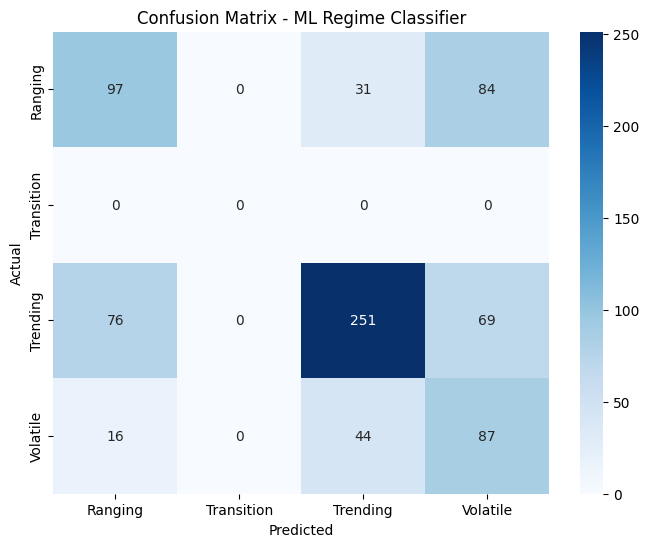

In [12]:
classes = regime_classifier.classes_
cm = confusion_matrix(y_test, y_pred_test, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title('Confusion Matrix - ML Regime Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance

In [13]:
importance_df = regime_classifier.get_feature_importance(top_n=15)
print(importance_df)

           feature  importance
65         vwap_20    0.110757
80      vol_regime    0.102746
63         vwap_10    0.065216
46          atr_50    0.047867
57   std_return_50    0.041866
61             obv    0.040768
44          atr_20    0.036850
32     macd_signal    0.034342
79        slope_50    0.027422
74             adx    0.026688
50   volatility_50    0.026461
6        return_50    0.025260
11  price_to_ma_50    0.024077
22  dist_to_low_50    0.021801
49   volatility_20    0.021396


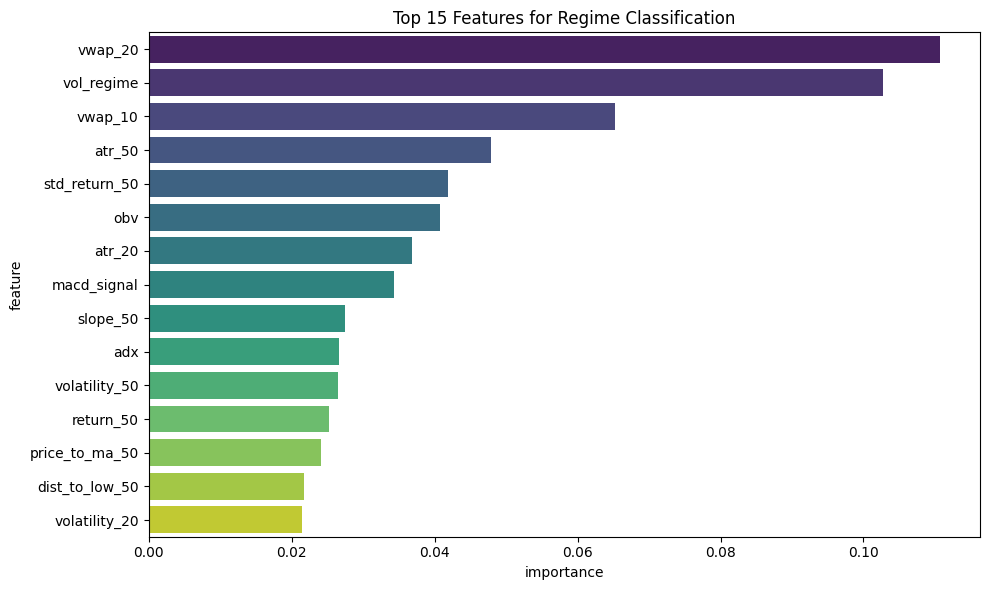

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
plt.title('Top 15 Features for Regime Classification')
plt.tight_layout()
plt.show()

### Compare ML vs Rule-Based Regime Detection

In [15]:
X_all_filled = X.ffill().bfill()
ml_regime_all = regime_classifier.predict(X_all_filled)

comparison_df = pd.DataFrame({
    'rule_based': y,
    'ml': ml_regime_all,
})

overall_agreement = (comparison_df['rule_based'] == comparison_df['ml']).mean()
print(f"Overall agreement: {overall_agreement:.2%}")
print("\nML regime distribution:")
print(comparison_df['ml'].value_counts().sort_index())
print("\nRule-based regime distribution:")
print(comparison_df['rule_based'].value_counts().sort_index())

Overall agreement: 77.93%

ML regime distribution:
ml
Ranging       933
Transition    107
Trending      971
Volatile      504
Name: count, dtype: int64

Rule-based regime distribution:
rule_based
Ranging        938
Transition     100
Trending      1177
Volatile       300
Name: count, dtype: int64


## 4. Train Signal Scorer

In [16]:
from src.ml.signal_scorer import SignalScorer
from src.strategies.backtest_py.runner import BacktestPyRunner
from src.strategies.connors_rsi import ConnorsRSIMeanReversion

C:\Dev\projects\investment_trying\.venv\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

### Generate Historical Signals & Label Profitable Trades

In [17]:
runner = BacktestPyRunner(data=df, cash=100000, verbose=False)
backtest_result = runner.run(ConnorsRSIMeanReversion)
trades = backtest_result.get('trades', [])
print(f"Generated {len(trades)} trades")

if len(trades) > 0:
    trades_df = pd.DataFrame(trades) if isinstance(trades, list) else trades
    if 'pnl' in trades_df.columns:
        trades_df["is_profitable"] = (trades_df["pnl"] > 0).astype(int)
        print(f"Profitable trades: {trades_df['is_profitable'].sum()}/{len(trades_df)} "
              f"({trades_df['is_profitable'].mean():.1%})")
        print("\nTrade P&L summary:")
        print(trades_df['pnl'].describe())
    else:
        print("No pnl column in trades - skipping signal scorer")
else:
    print("No trades generated - skipping signal scorer")


Backtest.run:   0%|          | 0/2315 [00:00<?, ?bar/s]

Generated 1 trades
Profitable trades: 0/1 (0.0%)

Trade P&L summary:
count      1.000000
mean    -860.942793
std             NaN
min     -860.942793
25%     -860.942793
50%     -860.942793
75%     -860.942793
max     -860.942793
Name: pnl, dtype: float64


C:\Dev\projects\investment_trying\src\strategies\backtest_py\runner.py:169: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  self.results = self.bt.run(**kwargs)  # type: ignore[union-attr]


In [18]:
if len(trades) > 0 and 'pnl' in trades_df.columns:
    trades_df = pd.DataFrame(trades) if isinstance(trades, list) else trades
    
    signal_feat_cols = ['entry_price', 'stop_loss', 'take_profit', 'atr_at_entry']
    available_cols = [c for c in signal_feat_cols if c in trades_df.columns]
    
    if available_cols:
        signal_X = trades_df[available_cols].copy()
        signal_y = (trades_df['pnl'] > 0).astype(int)
        
        signal_X = signal_X.ffill().bfill().dropna()
        signal_y = signal_y.loc[signal_X.index]
        
        if len(signal_X) >= 10:
            scorer = SignalScorer(
                model_type=CONFIG["ml"]["signal_model"],
                n_estimators=CONFIG["ml"]["n_estimators"],
                max_depth=CONFIG["ml"]["max_depth"],
                random_state=CONFIG["ml"]["random_state"],
            )
            try:
                signal_results = scorer.train(signal_X, signal_y)
                print("Signal Scorer Training Results:")
                for k, v in signal_results.items():
                    if isinstance(v, (int, float)):
                        print(f"  {k}: {v:.4f}")
                    elif isinstance(v, str):
                        print(f"  {k}: {v}")
            except Exception as e:
                print(f"Signal scorer training failed: {e}")
        else:
            print(f"Insufficient trades with features: {len(signal_X)} (need >=10)")
    else:
        print("No signal feature columns available in trades")
else:
    print("Skipping signal scorer - no valid trades")


Insufficient trades with features: 1 (need >=10)


## 5. Complete ML Pipeline

In [19]:
from src.ml.pipeline import MLPipeline

pipeline = MLPipeline(
    regime_model_type=CONFIG["ml"]["regime_model"],
    signal_model_type=CONFIG["ml"]["signal_model"],
    n_estimators=CONFIG["ml"]["n_estimators"],
    max_depth=CONFIG["ml"]["max_depth"],
    random_state=CONFIG["ml"]["random_state"],
)

In [20]:
pipeline_result = pipeline.run_pipeline(
    df=df,
    regime_labels=regime_labels,
    signal_features=None,
    signal_labels=None,
)

print("Pipeline Results:")
print(f"  Regime accuracy: {pipeline_result.pipeline_metrics['regime_accuracy']:.4f}")
print(f"  Features used: {pipeline_result.pipeline_metrics['n_features']}")

C:\Dev\projects\investment_trying\src\ml\features.py:541: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_5"] = -vol_rank5.rolling(5).corr(high_rank5).rolling(3).max()
C:\Dev\projects\investment_trying\src\ml\features.py:545: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_11"] = (
C:\Dev\projects\investment_trying\src\ml\features.py:552: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

C:\Dev\projects\investment_trying\src\ml\features.py:610: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_57"] = -(close - vwap_approx) / (decay_r.abs() + 1e-10) * 0.01
C:\Dev\projects\investment_trying\src\ml\features.py:615: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_65"] = -ts_r * np.sign(close.diff(7))
C:\Dev\projects\investment_trying\src\ml\features.py:619: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

C:\Dev\projects\investment_trying\src\ml\features.py:657: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_100"] = -high.rolling(5).corr(volume).rank(pct=True) * close.rolling(5).corr(volume).rank(pct=True)


C:\Dev\projects\investment_trying\src\ml\features.py:541: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_5"] = -vol_rank5.rolling(5).corr(high_rank5).rolling(3).max()
C:\Dev\projects\investment_trying\src\ml\features.py:545: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_11"] = (
C:\Dev\projects\investment_trying\src\ml\features.py:552: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

C:\Dev\projects\investment_trying\src\ml\features.py:610: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_57"] = -(close - vwap_approx) / (decay_r.abs() + 1e-10) * 0.01


C:\Dev\projects\investment_trying\src\ml\features.py:615: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_65"] = -ts_r * np.sign(close.diff(7))
C:\Dev\projects\investment_trying\src\ml\features.py:619: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_68"] = np.where(high.rolling(9).corr(adv15) < close.diff(3), -1.0, 1.0)
C:\Dev\projects\investment_trying\src\ml\features.py:626: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

C:\Dev\projects\investment_trying\src\ml\features.py:541: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_5"] = -vol_rank5.rolling(5).corr(high_rank5).rolling(3).max()
C:\Dev\projects\investment_trying\src\ml\features.py:545: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_11"] = (
C:\Dev\projects\investment_trying\src\ml\features.py:552: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

C:\Dev\projects\investment_trying\src\ml\features.py:610: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_57"] = -(close - vwap_approx) / (decay_r.abs() + 1e-10) * 0.01


Pipeline Results:
  Regime accuracy: 0.7443
  Features used: 125


C:\Dev\projects\investment_trying\src\ml\features.py:615: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_65"] = -ts_r * np.sign(close.diff(7))
C:\Dev\projects\investment_trying\src\ml\features.py:619: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_68"] = np.where(high.rolling(9).corr(adv15) < close.diff(3), -1.0, 1.0)
C:\Dev\projects\investment_trying\src\ml\features.py:626: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

## 6. Walk-Forward Validation

In [21]:
pipeline2 = MLPipeline(
    regime_model_type=CONFIG["ml"]["regime_model"],
    n_estimators=CONFIG["ml"]["n_estimators"],
    max_depth=CONFIG["ml"]["max_depth"],
    random_state=CONFIG["ml"]["random_state"],
)

wf_results = pipeline2.walk_forward_validation(
    df=df,
    regime_labels=regime_labels,
    signal_features=None,
    signal_labels=None,
)

if "regime" in wf_results:
    print("Walk-Forward Regime Results:")
    regime_wf = wf_results["regime"]
    for k, v in regime_wf.items():
        if isinstance(v, (int, float)):
            print(f"  {k}: {v:.4f}")
        elif isinstance(v, list):
            print(f"  {k} ({len(v)} folds): {np.mean(v):.4f} +/- {np.std(v):.4f}")

C:\Dev\projects\investment_trying\src\ml\features.py:541: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_5"] = -vol_rank5.rolling(5).corr(high_rank5).rolling(3).max()
C:\Dev\projects\investment_trying\src\ml\features.py:545: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_11"] = (
C:\Dev\projects\investment_trying\src\ml\features.py:552: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

C:\Dev\projects\investment_trying\src\ml\features.py:610: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_57"] = -(close - vwap_approx) / (decay_r.abs() + 1e-10) * 0.01


C:\Dev\projects\investment_trying\src\ml\features.py:615: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_65"] = -ts_r * np.sign(close.diff(7))
C:\Dev\projects\investment_trying\src\ml\features.py:619: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["alpha_68"] = np.where(high.rolling(9).corr(adv15) < close.diff(3), -1.0, 1.0)
C:\Dev\projects\investment_trying\src\ml\features.py:626: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

Walk-Forward Regime Results:
  train_score (23 folds): 0.9652 +/- 0.0223
  test_score (23 folds): 0.4352 +/- 0.2189


## 7. Summary & Conclusions

In [22]:
summary = {
    "ML Regime Accuracy": f"{ml_accuracy:.2%}",
    "Rule-Based vs ML Agreement": f"{overall_agreement:.2%}",
    "Features Generated": str(len(numeric_features.columns)),
    "Training Samples": str(len(numeric_features)),
    "Regime Class Distribution": regime_labels.value_counts().to_dict(),
}

print("=" * 60)
print("ML VALIDATION SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k}: {v}")

print("\n" + "=" * 60)
print("NEXT STEPS")
print("=" * 60)
if ml_accuracy > 0.7:
    print("  ML regime detection shows promise (>70% accuracy)")
    print("  -> Integrate with ConfluenceScorer for ML-enhanced signal scoring")
    print("  -> Run full backtest with ML enhancement")
else:
    print("  ML regime accuracy is not significantly better than random")
    print("  -> Try feature engineering improvements")
    print("  -> Consider different model types (XGBoost, neural nets)")
    print("  -> Add more input features (volume, volatility, cross-asset)")

ML VALIDATION SUMMARY
  ML Regime Accuracy: 57.62%
  Rule-Based vs ML Agreement: 77.93%
  Features Generated: 125
  Training Samples: 2515
  Regime Class Distribution: {'Trending': 1177, 'Ranging': 938, 'Volatile': 300, 'Transition': 100}

NEXT STEPS
  ML regime accuracy is not significantly better than random
  -> Try feature engineering improvements
  -> Consider different model types (XGBoost, neural nets)
  -> Add more input features (volume, volatility, cross-asset)
